# Magnetic Fields (MHD)

Mera reads **RAMSES MHD** (ideal magnetohydrodynamics) outputs and exposes the magnetic field for
analysis. RAMSES evolves **B** with a *constrained-transport* scheme, so the field is stored as the
**six face-centred components** `B_{x,y,z}_left` and `B_{x,y,z}_right` in the ordinary hydro files
(there are no separate magnetic-field files). The physically meaningful **cell-centred** field is the
average of the two opposing faces,

```math
B_i = \tfrac12\,(B_{i,\text{left}} + B_{i,\text{right}}), \qquad i\in\{x,y,z\}.
```

## How Mera detects and names MHD variables

In an MHD hydro file the variable order is

```
density, vx, vy, vz, B_x_left, B_y_left, B_z_left, B_x_right, B_y_right, B_z_right, [non-thermal], pressure, [scalars…]
```

so the thermal **pressure sits at index 11**, not 5 (index 5 is `B_x_left`). Mera handles this
automatically across RAMSES versions:

- **With a `hydro_file_descriptor.txt`** (post-2019 and 2025 outputs) Mera reads the variable names
  directly and maps them to its canonical symbols (`density→:rho`, `velocity_*→:vx/:vy/:vz`,
  `pressure→:p` at its true index, `B_*_{left,right}→:b*_{left,right}`).
- **Without a descriptor** (older outputs) Mera uses the community heuristic (matching `yt`): a 3-D run
  with `nvar ≥ 11` is treated as MHD (the constrained-transport module adds the three `B_right`
  components). A short `@info` line is printed when this heuristic is applied.

Either way you get canonical names and the cell-centred field `:bx`, `:by`, `:bz`.

!!! note "Ambiguous no-descriptor case"
    Without a descriptor, a *hydro* run that happens to carry exactly six passive scalars also has
    `nvar = 11` and would be read as MHD. Modern RAMSES writes the descriptor, which removes the
    ambiguity; if you hit this, the columns are still available positionally (`:var6…`).

!!! note "MHD support is still growing"
    Reading and the derived quantities are in place and tested against RAMSES's own reference
    solutions. Higher-level MHD tooling is still being added, so if something you need is missing,
    say so on the issue tracker.

## The example data

Two public test simulations are used here. Both are fetched with `download_testdata`, so every
cell on this page runs on data you can get.

| | what it is | why it is here |
|---|---|---|
| `ramses_abc_flow` | a 3-D MHD dynamo, 32³ cells | the working example: real field structure in all three directions |
| `ramses_mhd_128` | a 1-D shock tube, 128³ | a known answer, used once to check the reader |

Everything below the first section uses the 3-D run. Analysis on a real simulation looks the same:
only the path changes.

In [1]:
# Example-data root. Point this at your own simulation folder, or set the
# MERA_EXAMPLES environment variable; every path below is built from it.
MERA_EXAMPLES = get(ENV, "MERA_EXAMPLES", "/Volumes/FASTStorage/Simulations/Mera-Tests");

using Mera
info = getinfo(2, "$MERA_EXAMPLES/RAMSES-PUBLIC/ramses_abc_flow");


*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0 | Julia 1.12.7 | 4 threads

[Mera]: 2026-09-14T15:13:42.228



Code: 

RAMSES
output [2] summary:
mtime: 2026-08-26T15:14:12.234
ctime: 2026-08-26T15:14:12.234
simulation time: 10.0 [s]
boxlen: 1.0 [cm]
ncpu: 8
ndim: 3
cosmological:  false
-------------------------------------------------------
amr:           true
level of uniform grid: 5 --> cellsize(s): 312.5 [μm]
-------------------------------------------------------
hydro:         true
hydro-variables:  

11  --> (:rho, :vx, :vy, :vz, :bx_left, :by_left, :bz_left, :bx_right, :by_right, :bz_right, :p)
hydro-descriptor: (:density, :velocity_x, :velocity_y, :velocity_z, :B_x_left, :B_y_left, :B_z_left, :B_x_right, :B_y_right, :B_z_right, :pressure)
magnetic field:   true (MHD, constrained transport) --> cell-centred :bx, :by, :bz = ½(left+right)
γ: 1.6666667
gravity:       false
particles:     false
rt:            false
clumps:           false
-------------------------------------------------------
namelist-file: (

"&HYDRO_PARAMS", "&INIT_PARAMS", "&RUN_PARAMS", "&AMR_PARAMS", "&OUTPUT_PARAMS", "&REFINE_PARAMS")
-------------------------------------------------------
boundaries:       periodic in x, y, z
timer-file:       true
compilation-file: true
makefile:         true
patchfile:        true



`getinfo` prints the MHD note above: it found the six face-centred B components and moved the
pressure to index 11. Nothing else is needed to read an MHD run.

The field is an Arnold-Beltrami-Childress flow, a standard dynamo test. The gas has uniform density
and nearly uniform pressure, so all the structure is in **B**, which is what we want on this page.

In [2]:
gas = gethydro(info, verbose=false, show_progress=false);

println("cells            : ", length(gas.data))
println("density  rho     : ", extrema(getvar(gas, :rho)))
println("pressure p       : ", extrema(getvar(gas, :p)))
println("Bx               : ", extrema(getvar(gas, :bx)))
println("By               : ", extrema(getvar(gas, :by)))
println("Bz               : ", extrema(getvar(gas, :bz)))

cells            : 32768


density  rho     : (1.0, 1.0)
pressure p       : (0.659861938296692, 0.6692781818855303)
Bx               : (-0.8097685225907696, 0.8097685225907915)
By               : (-0.8097685225907656, 0.8097685225907907)
Bz               : (-0.19385135316944382, 0.9874378684150922)


## Derived magnetic quantities

These are **built-in `getvar` quantities**, computed from the cell-centred field. No manual
arithmetic, and each takes a unit. This run is dimensionless (it sets `unit_l = unit_d = unit_t = 1`),
so the numbers below are code units; on a run with physical scaling the same calls give μG, km/s
and erg.

In [3]:
bmag = getvar(gas, :bmag)          # |B|
beta = getvar(gas, :beta)          # plasma beta = p_thermal / p_magnetic
va   = getvar(gas, :v_alfven)      # Alfven speed
mA   = getvar(gas, :mach_alfven)   # Mach numbers are ratios, dimensionless in any unit system

println("|B|           : ", extrema(bmag))
println("plasma beta   : ", extrema(beta))
println("  spanning    : ", round(log10(maximum(beta)/minimum(beta)), digits=1), " decades")
println("Alfven speed  : ", extrema(va))
println("Mach_alfven   : ", extrema(mA))

[Mera] Hint: getvar(:v) has no `vcenter` — velocities are in the BOX frame.


             Pass vcenter=:auto for an object with bulk motion (`center=` sets the origin,
             `vcenter=` the frame). On a halo streaming at ~200 km/s this shifted |J| by 34 %.
             (shown once per session; verbose(false) silences Mera's messages)
|B|           : (0.0015395372898541501, 1.401162752947759)
plasma beta   : (0.6807865656874684, 562546.4074980728)
  spanning    : 5.9 decades
Alfven speed  : (0.0015395372898541501, 1.401162752947759)
Mach_alfven   : (0.0989300985252919, 1346.9642077736057)


Plasma beta runs over nearly six decades here, from magnetically dominated (β < 1) to strongly
thermally dominated. That range is what makes the plots below worth looking at.

Almost no new units were needed: `B` reuses the field-strength scales (`:Gauss`, `:muG`, `:microG`,
`:nG`, `:Tesla`), magnetic pressure/energy-density reuse the pressure scales (`:Ba`, `:g_cm_s2`), the
Alfvén speed reuses the velocity scales (`:km_s`, `:cm_s`), and the magnetic energy reuses `:erg`.
(`:nG`, nanogauss, was added via a new `ScalesType003` so pre-existing mera files still load.)

The exact formulas (incl. the RAMSES code-unit convention `P_mag = B²/2` and the Alfvén-speed
conversion) are listed in
[How Quantities Are Computed](computation_reference.md#Magnetic-quantities).

## Maps

The cell-centred components project like any other quantity. A map of `|B|` shows where the field
is strong; a map of a single component shows its sign, so it wants a diverging colour scale.

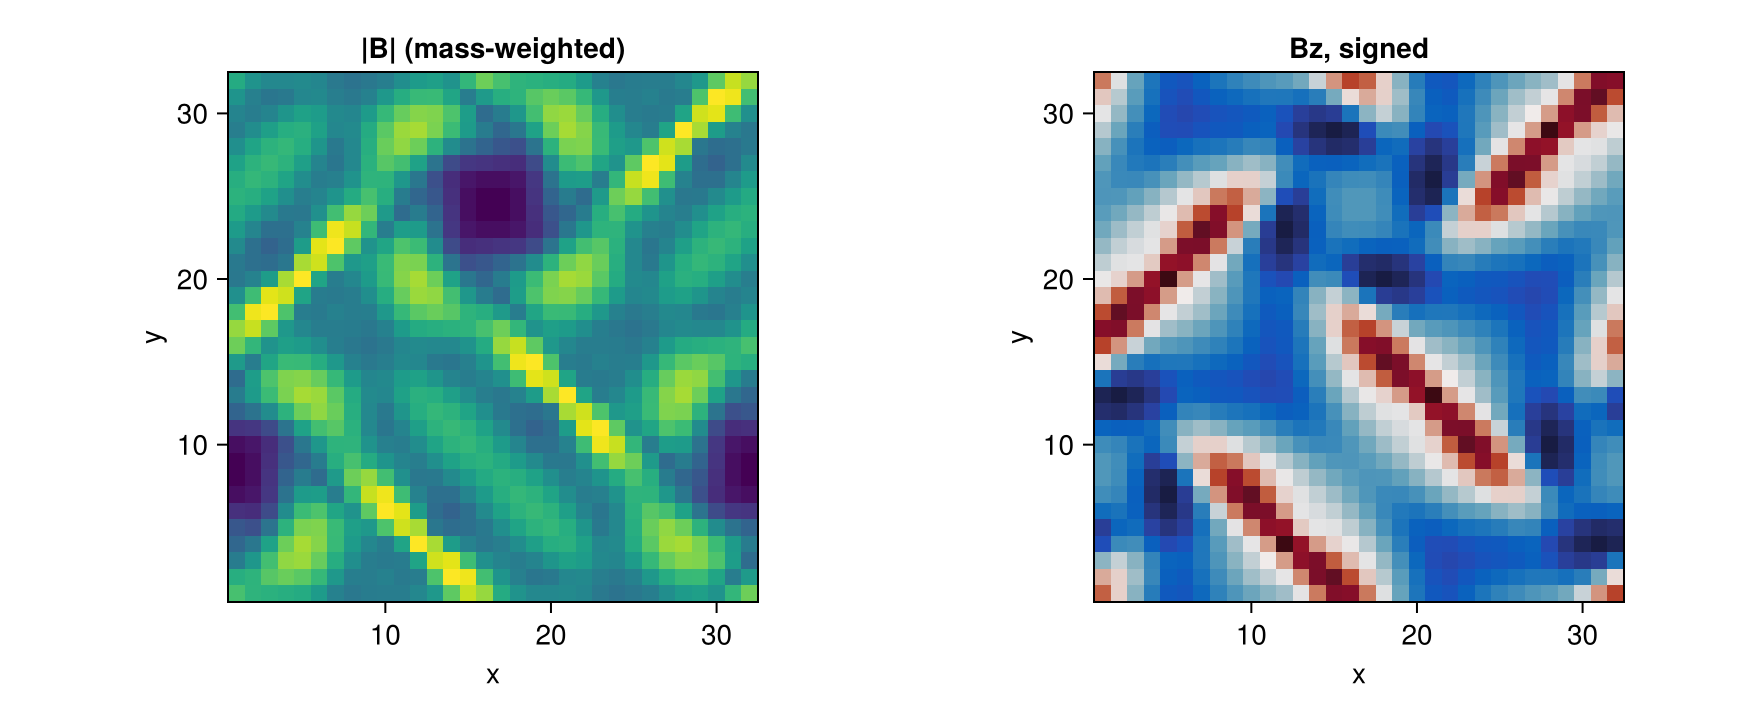

In [4]:
using CairoMakie

p = projection(gas, [:bmag, :bz]; verbose=false, show_progress=false)

fig = Figure(size=(880, 360))
ax1 = Axis(fig[1,1]; title="|B| (mass-weighted)", aspect=DataAspect(), xlabel="x", ylabel="y")
ax2 = Axis(fig[1,2]; title="Bz, signed",          aspect=DataAspect(), xlabel="x", ylabel="y")
heatmap!(ax1, p.maps[:bmag]; colormap=:viridis)
heatmap!(ax2, p.maps[:bz];   colormap=:balance)
fig

A projection sums along the line of sight, so it averages away some of the structure. To see a
plane of the box instead, restrict the third axis: this is a slice one cell thick.

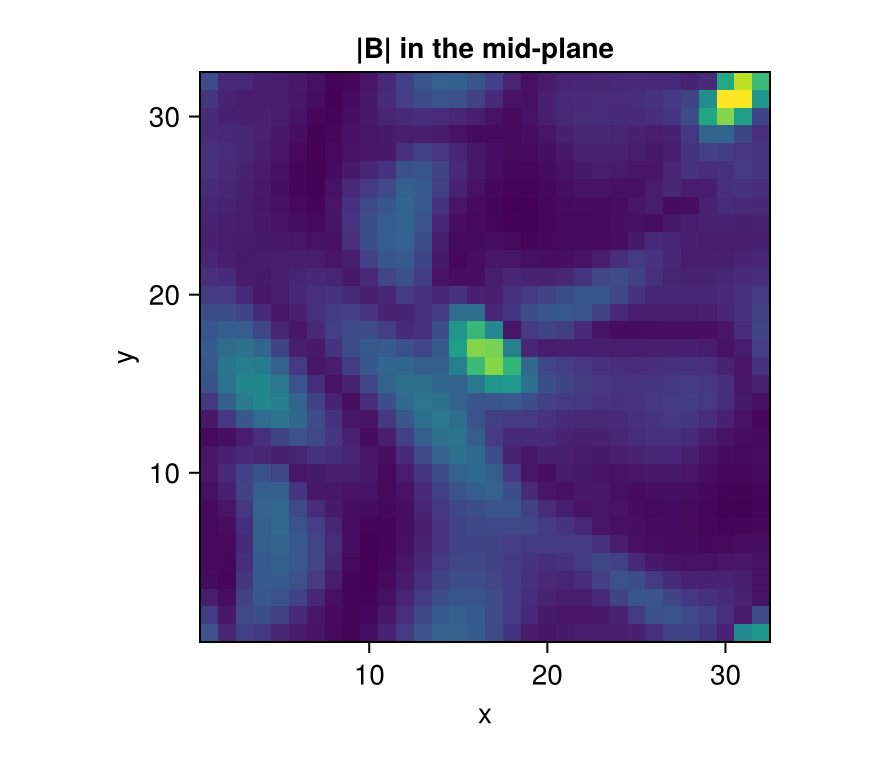

In [5]:
dz = info.boxlen / 2^info.levelmin          # one cell at the coarse level
sl = projection(gas, :bmag; zrange=[0.5 - dz/2, 0.5 + dz/2], center=[:bc],
                range_unit=:standard, verbose=false, show_progress=false)

fig = Figure(size=(440, 380))
ax  = Axis(fig[1,1]; title="|B| in the mid-plane", aspect=DataAspect(), xlabel="x", ylabel="y")
heatmap!(ax, sl.maps[:bmag]; colormap=:viridis)
fig

## Distributions

A **PDF** answers a question a map cannot: how much of the gas sits at each value. Weight by mass,
so the answer is a mass fraction and not a cell count. Here it shows how the volume divides between
magnetically and thermally dominated gas, with β = 1 marking the boundary.

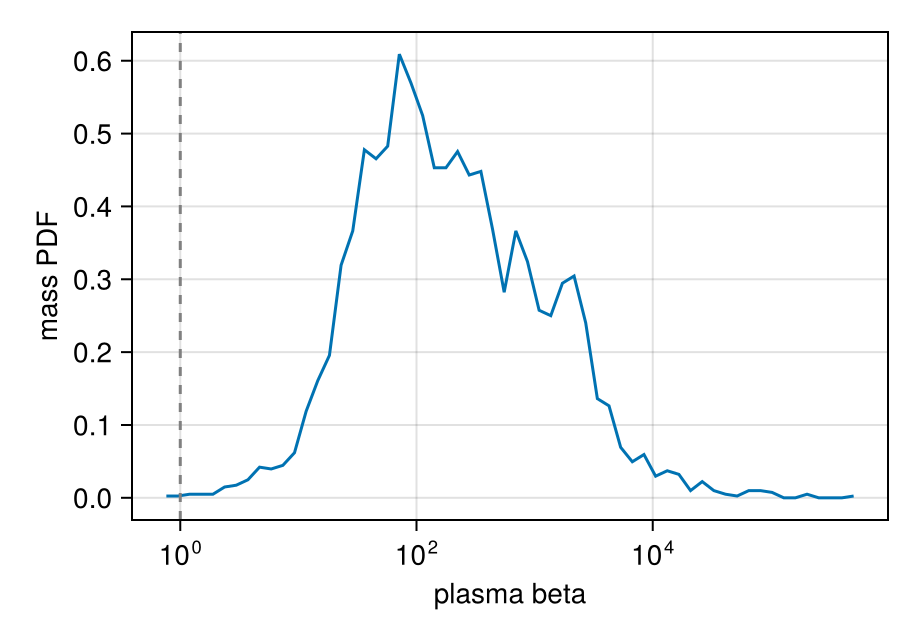

In [6]:
pb = pdf(gas, :beta; weight=:mass)

fig = Figure(size=(460, 320))
ax  = Axis(fig[1,1]; xlabel="plasma beta", ylabel="mass PDF", xscale=log10)
lines!(ax, pb.centers, pb.pdf)
vlines!(ax, [1.0]; color=:grey, linestyle=:dash)     # equipartition
fig

## Phase diagrams

`phase` is the two-dimensional version: a weighted histogram of one quantity against another. On a
production run this is the classic density-temperature diagram. Here, with density uniform, the
informative pair is field strength against plasma beta, and the two are tightly related because the
pressure hardly varies.

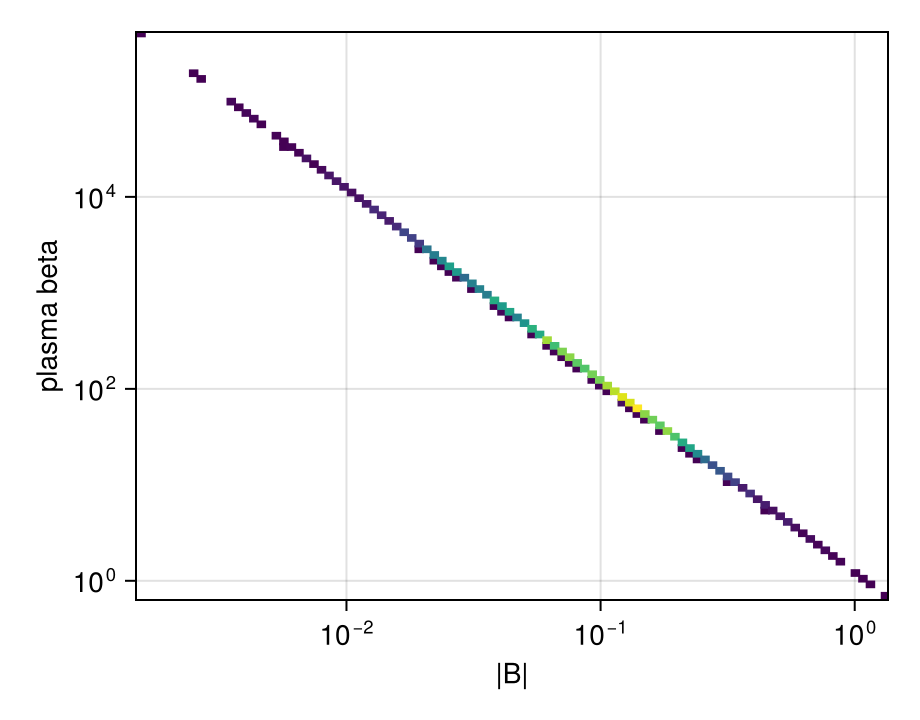

In [7]:
# log-spaced bins, so both axes can be shown on a log scale
ph = phase(gas, :bmag, :beta; weight=:mass, xscale=:log, yscale=:log)

fig = Figure(size=(460, 360))
ax  = Axis(fig[1,1]; xlabel="|B|", ylabel="plasma beta", xscale=log10, yscale=log10)
heatmap!(ax, ph.xedges[1:end-1], ph.yedges[1:end-1], replace(ph.H, 0.0 => NaN); colormap=:viridis)
fig

## Profiles

`profile` bins any quantity against any other. A radial profile about the box centre shows how the
field strength is organised with distance. Weight by `:volume`, because we are averaging cells and
this run has uniform density anyway.

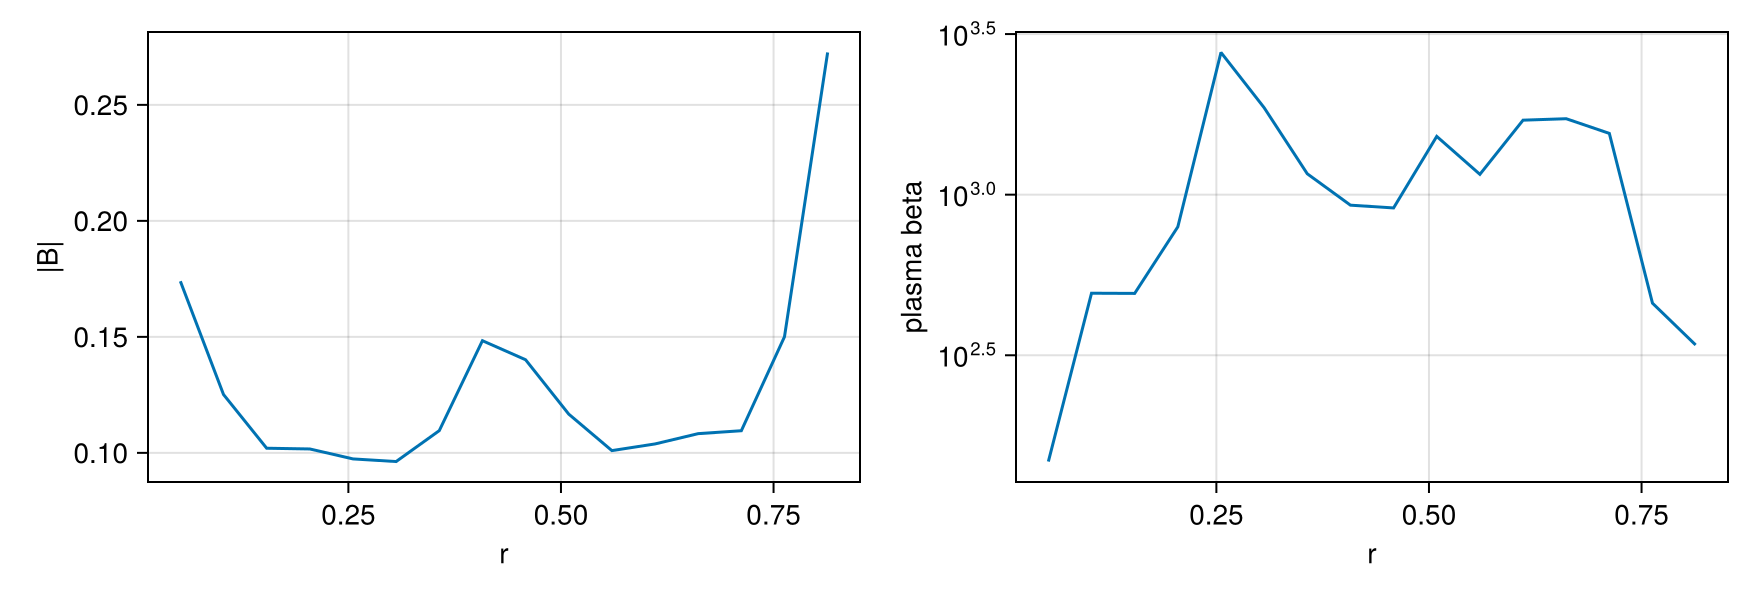

In [8]:
pr = profile(gas, :r_sphere, [:bmag, :beta]; center=[:bc], nbins=16, weight=:volume)

fig = Figure(size=(880, 300))
for (n, (q, lab)) in enumerate(((:bmag, "|B|"), (:beta, "plasma beta")))
    ax = Axis(fig[1, n]; xlabel="r", ylabel=lab, yscale = q === :beta ? log10 : identity)
    lines!(ax, pr.x, pr.fields[q].mean)
end
fig

Each field carries more than the mean: `std`, `min`, `max`, `median`, `quantiles` and the
effective count per bin come back in the same pass, so a spread band costs nothing extra.

In [9]:
m, s = pr.fields[:bmag].mean, pr.fields[:bmag].std
println("bins                : ", length(m))
println("cells in the first  : ", Int(round(pr.count[1])))
println("spread/mean, bin 1  : ", round(s[1]/m[1], digits=3))

bins                : 16
cells in the first  : 56
spread/mean, bin 1  : 0.438


## Selecting part of the box

A region behaves the same on MHD data as on any other. Because the selection carries a per-cell
fraction for the cells the boundary cuts, a magnetic energy summed over a sphere is the energy
inside the sphere, not the energy of every cell the sphere touches.

In [10]:
# CairoMakie also exports a `Sphere`, so qualify Mera's region type once the
# plotting package is loaded. `Mera.Sphere` is unambiguous either way.
region = Mera.Sphere(0.3; center=[:bc], range_unit=:standard)

sph = subregion(gas, region, verbose=false)
println("cells in the sphere   : ", length(sph.data))
println("magnetic energy       : ", round(sum(getvar(sph, :e_magnetic)), sigdigits=6))
println("  counting whole cells: ",
        round(sum(getvar(subregion(gas, region, split=false, verbose=false), :e_magnetic)),
              sigdigits=6))

cells in the sphere   : 4632


magnetic energy       : 

0.000906972
  counting whole cells: 0.000891642


## Checking the reader against a known answer

The 3-D run above shows what the tools do. This last section does something different: it checks
that the **reader** is right, using a problem whose answer is known in advance.

`ramses_mhd_128` is a 1-D MHD shock tube along `x`, extruded in `y` and `z`. Nothing varies across
the tube, so ``\nabla\cdot\mathbf B = 0`` reduces to ``\partial B_x/\partial x = 0``: `Bx` has to
be constant everywhere, to machine precision. RAMSES stores the field on cell **faces**, and Mera
averages opposing faces to get the cell-centred value. If that averaging were wrong, a constant
would not come back constant, so this is a real test and it costs nothing to run.

The third line checks the other half of the setup, that nothing varies across the tube. Note the
`center=[:bc]`: `getvar(:x)` measures from the box **corner** unless you give it an origin, so
without it the selection would be empty and the test would pass by accident.

In [11]:
using Statistics

tube = gethydro(getinfo(27, "$MERA_EXAMPLES/RAMSES/ramses_mhd_128", verbose=false),
                verbose=false, show_progress=false)

bx = getvar(tube, :bx)
println("Bx constant (div B = 0 in 1-D) : ", all(bx .== first(bx)))
println("Bz identically zero            : ", all(iszero, getvar(tube, :bz)))

xc = getvar(tube, :x, center=[:bc])
println("nothing varies across the tube : ",
        std(getvar(tube, :rho)[xc .< -0.9]) < 1e-12)

[ Info: Mera: no hydro descriptor and nvarh=11 (≥11) on a 3D run — assuming a RAMSES MHD layout (B faces at 5–10, pressure at 11). If this is hydro with ≥6 passive scalars instead, the names are positional (:var6…).


Bx constant (div B = 0 in 1-D) : true


Bz identically zero            : true
nothing varies across the tube : true


Three `true` values. The same check is part of the test suite, run against RAMSES's own published
reference solution for this problem, so it is not only checked here.

On an MHD run the [first-look dashboard](report.md) does this for you: `quicklook(output)` adds a
face-on `|B|` panel and reports the `|B|` and plasma-β ranges automatically.

## Caveats

- Mera reads **ideal-MHD** RAMSES outputs (the constrained-transport `B` faces). Non-ideal terms
  (e.g. resistivity) are not separate fields.
- `:bx/:by/:bz` are the **cell-centred** average of the faces; the raw faces remain available as
  `:bx_left`, `:bx_right`, … if you need the divergence-free face representation.
- On a non-MHD run, `:bx/:by/:bz`, the derived quantities (`:bmag`, `:pmag`, `:beta`, `:v_alfven`,
  `:e_magnetic`) and the magnetosonic Mach numbers all error with a clear message.
- The face-centred components stay available as `:bx_left`, `:bx_right` and so on, if you need the
  divergence-free face representation rather than the cell-centred average.